# Chase Analytics Notebook


Ιστορική ανάλυση των training logs ανά run/sheet (FP vs FP, MinimaxQ self-play, MinimaxQ vs FP).
Rolling averages σε capture rate και steps, split ανά p_fail (0.1 / 0.2).
Σημείωση: τα evaluate episodes δεν logάρονται, οπότε ό,τι βλέπουμε είναι μόνο training.


## 0. Setup
Import libraries, paths, and helper utilities.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_DIR = Path(__file__).parent if '__file__' in globals() else Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
RESULTS_PATH = PROJECT_ROOT / 'results' / 'chase_run.xlsx'
ROLL_WINDOW = 400  # episodes for rolling averages

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from nb_utils import *

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

print(f'Notebook dir: {NOTEBOOK_DIR}')
print(f'Results file: {RESULTS_PATH}')


Notebook dir: c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook
Results file: C:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\results\chase_run.xlsx


## 1. Load data & list runs
Load all sheets (runs) from the Excel log.


In [2]:
sheets = load_runs(RESULTS_PATH)
print('Sheets found:')
for name, df in sheets.items():
    print(f'  {name}: {len(df):,} rows')


Sheets found:
  fp_vs_fp: 66,694 rows
  minimaxq_selfplay: 349,404 rows
  minimaxq_vs_fp: 564,618 rows


## 2. Quick peek (first sheet)
See the first few rows to remember the columns.


In [3]:
run_name = next(iter(sheets))
sheets[run_name].head()


,run,p_fail,env_size,env_t_max,env_step_penalty,env_seed,episode,step,env_t,sid,sid_next,catcher_x,catcher_y,runner_x,runner_y,catcher_action_id,runner_action_id,catcher_action,runner_action,catcher_x_next,catcher_y_next,runner_x_next,runner_y_next,reward,capture,done,c_fail,r_fail,value_estimate,epsilon,catcher_agent,runner_agent,opp_pi_catcher,opp_pi_runner
0,fp_vs_fp,0.1,5,30,0.01,0,1,1,1,452,326,3,3,0,2,2,3,DOWN,LEFT,2,3,0,1,-0.01,False,False,False,False,NaN,NaN,FP,FP,"[0.19999999995999998, 0.19999999995999998, 0.1...","[0.19999999995999998, 0.19999999995999998, 0.1..."
1,fp_vs_fp,0.1,5,30,0.01,0,1,2,2,326,300,2,3,0,1,3,3,LEFT,LEFT,2,2,0,0,-0.01,False,False,False,False,NaN,NaN,FP,FP,"[0.19999999995999998, 0.19999999995999998, 0.1...","[0.19999999995999998, 0.19999999995999998, 0.1..."
2,fp_vs_fp,0.1,5,30,0.01,0,1,3,3,300,175,2,2,0,0,2,3,DOWN,LEFT,1,2,0,0,-0.01,False,False,False,False,NaN,NaN,FP,FP,"[0.19999999995999998, 0.19999999995999998, 0.1...","[0.19999999995999998, 0.19999999995999998, 0.1..."
3,fp_vs_fp,0.1,5,30,0.01,0,1,4,4,175,150,1,2,0,0,3,2,LEFT,DOWN,1,1,0,0,-0.01,False,False,False,False,NaN,NaN,FP,FP,"[0.19999999995999998, 0.19999999995999998, 0.1...","[0.19999999995999998, 0.19999999995999998, 0.1..."
4,fp_vs_fp,0.1,5,30,0.01,0,1,5,5,150,25,1,1,0,0,2,3,DOWN,LEFT,0,1,0,0,-0.01,False,False,False,False,NaN,NaN,FP,FP,"[0.19999999995999998, 0.19999999995999998, 0.1...","[0.19999999995999998, 0.19999999995999998, 0.1..."


## 3. Combine & enrich
- Attach all sheets into a single step-level DataFrame.
- Add derived columns.
- Compute episode-level metrics and rolling averages.

In [4]:
steps_df = add_derived_columns(combine_runs(sheets))
ep_df = episode_metrics(steps_df)
summary_df = capture_rate_by_run(ep_df)
roll_df = rolling_episode_metrics(ep_df, window=ROLL_WINDOW)

print(f'Step rows total: {len(steps_df):,}')
print(f'Episode rows total: {len(ep_df):,}')
display(summary_df)


Step rows total: 980,716
Episode rows total: 44,000


c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:143: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return ep_df.groupby(["run", "p_fail"], group_keys=False).apply(_add_roll)


,run,p_fail,capture_rate,avg_steps,avg_return
0,fp_vs_fp,0.1,0.7350,18.1025,0.561325
1,fp_vs_fp,0.2,0.8490,15.2445,0.705045
2,minimaxq_selfplay,0.1,0.6756,18.7777,0.494579
3,minimaxq_selfplay,0.2,0.7765,16.1627,0.622638
4,minimaxq_vs_fp,0.1,0.1321,28.2246,-0.148825
5,minimaxq_vs_fp,0.2,0.1362,28.2372,-0.144810


## 4. Training History
Training history plots per run type:
- FP self-play
- MinimaxQ self-play
- MinimaxQ (catcher) vs FP (runner)

* Rolling capture rate and steps per episode for the FP self-play.

,run,p_fail,capture_rate,avg_steps,avg_return
0,fp_vs_fp,0.1,0.735,18.1025,0.561325
1,fp_vs_fp,0.2,0.849,15.2445,0.705045


c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:143: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return ep_df.groupby(["run", "p_fail"], group_keys=False).apply(_add_roll)


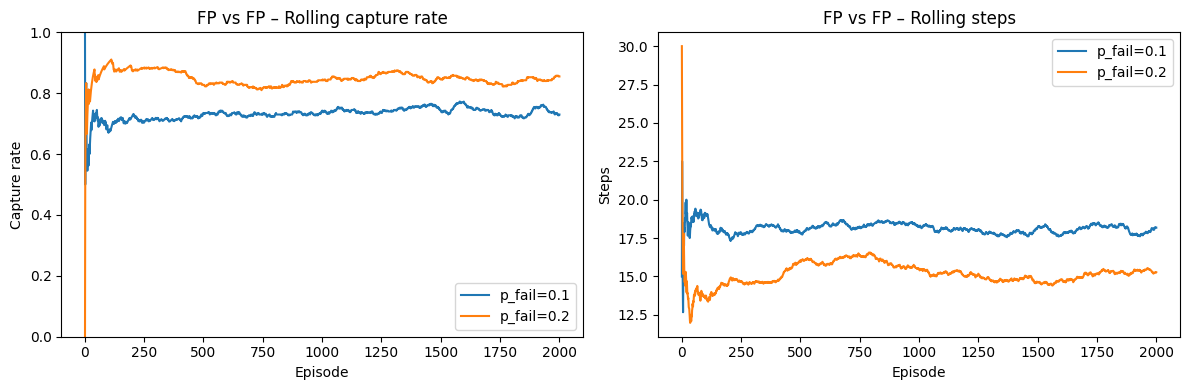

In [5]:
run_fp = 'fp_vs_fp'
fp_ep = ep_df.loc[ep_df['run'] == run_fp]
if fp_ep.empty:
    print('No data for FP vs FP')
else:
    display(summary_df.loc[summary_df['run'] == run_fp])
    plot_run_trends(fp_ep, run=run_fp, window=ROLL_WINDOW, title_prefix='FP vs FP')
    plt.show()


* Rolling capture rate and steps per episode for MinimaxQ vs MinimaxQ.


,run,p_fail,capture_rate,avg_steps,avg_return
2,minimaxq_selfplay,0.1,0.6756,18.7777,0.494579
3,minimaxq_selfplay,0.2,0.7765,16.1627,0.622638


c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:143: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return ep_df.groupby(["run", "p_fail"], group_keys=False).apply(_add_roll)


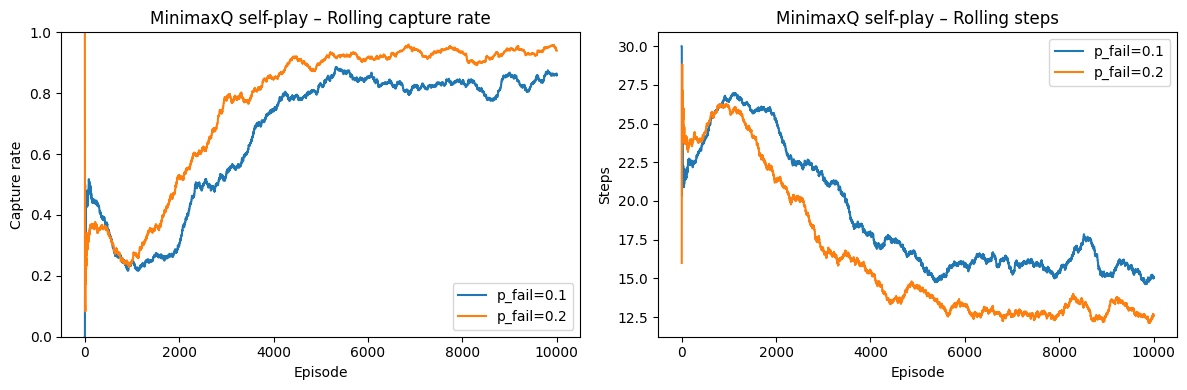

In [6]:
run_mm = 'minimaxq_selfplay'
mm_ep = ep_df.loc[ep_df['run'] == run_mm]
if mm_ep.empty:
    print('No data for MinimaxQ self-play')
else:
    display(summary_df.loc[summary_df['run'] == run_mm])
    plot_run_trends(mm_ep, run=run_mm, window=ROLL_WINDOW, title_prefix='MinimaxQ self-play')
    plt.show()


* Rolling capture rate and steps per episode for the mixed matchup, MinimaxQ (catcher) vs FP (runner).


,run,p_fail,capture_rate,avg_steps,avg_return
4,minimaxq_vs_fp,0.1,0.1321,28.2246,-0.148825
5,minimaxq_vs_fp,0.2,0.1362,28.2372,-0.144810


c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:143: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return ep_df.groupby(["run", "p_fail"], group_keys=False).apply(_add_roll)


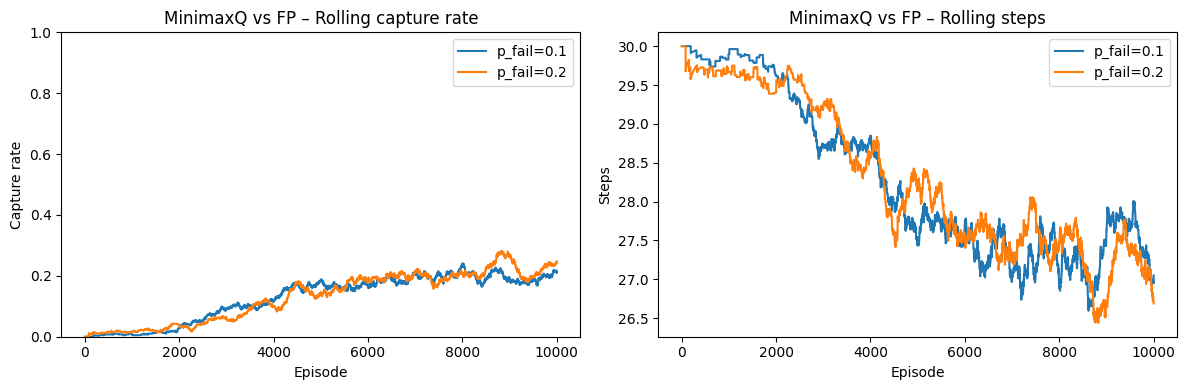

In [7]:
run_mix = 'minimaxq_vs_fp'
mix_ep = ep_df.loc[ep_df['run'] == run_mix]
if mix_ep.empty:
    print('No data for MinimaxQ vs FP')
else:
    display(summary_df.loc[summary_df['run'] == run_mix])
    plot_run_trends(mix_ep, run=run_mix, window=ROLL_WINDOW, title_prefix='MinimaxQ vs FP')
    plt.show()


## 5. Action drift over training
Rolling action mix (stacked area) per run and p_fail.


c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g.groupby(["episode", col])
c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:177: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_group)


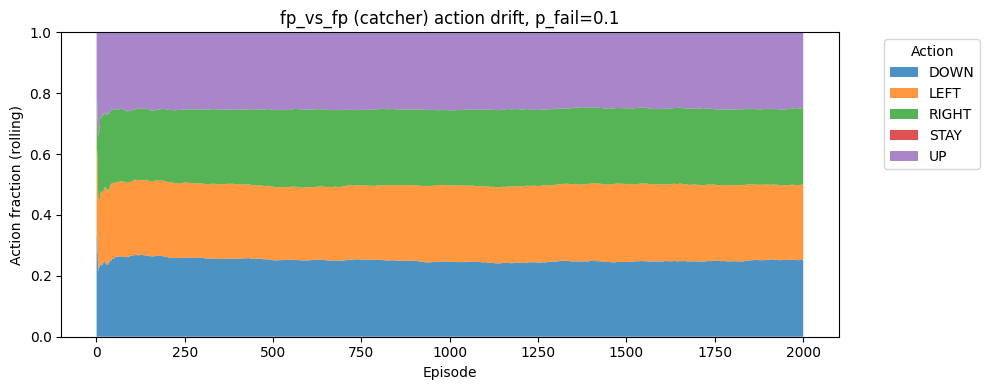

c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g.groupby(["episode", col])
c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:177: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_group)


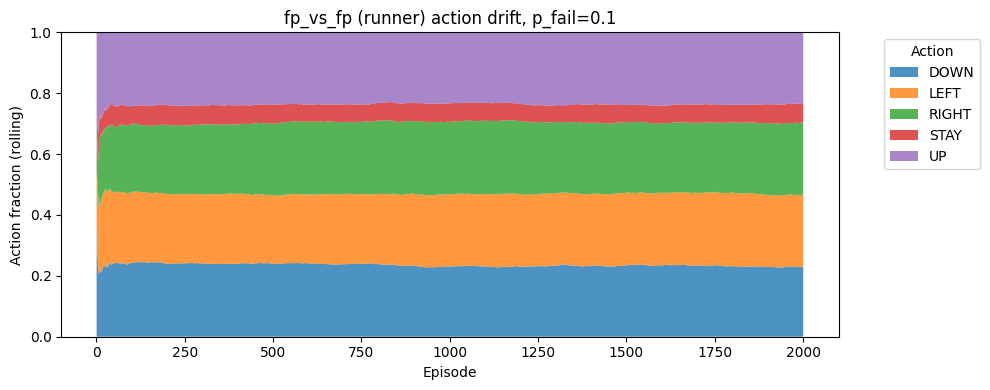

c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g.groupby(["episode", col])
c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:177: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_group)


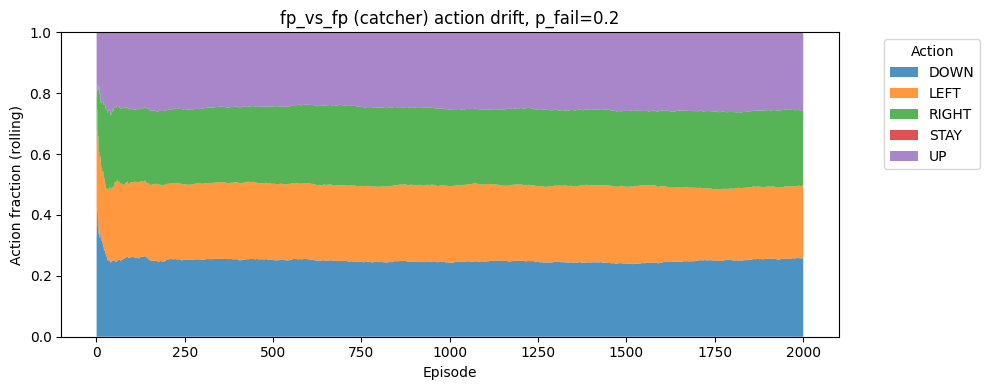

c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g.groupby(["episode", col])
c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:177: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_group)


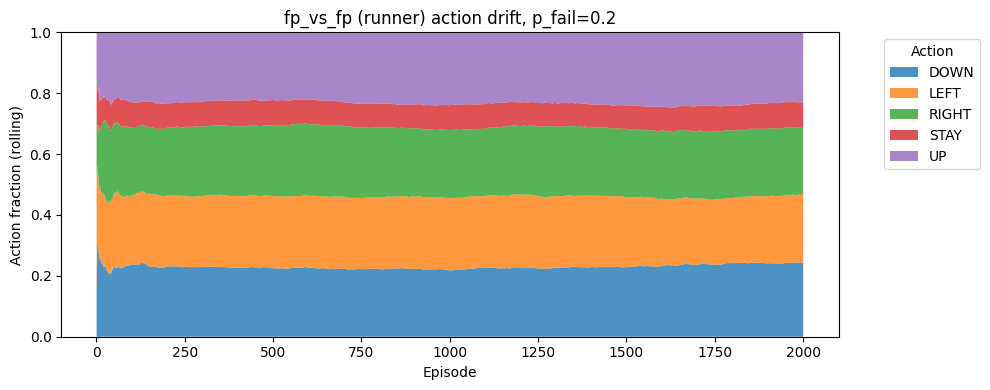

c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g.groupby(["episode", col])
c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:177: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_group)


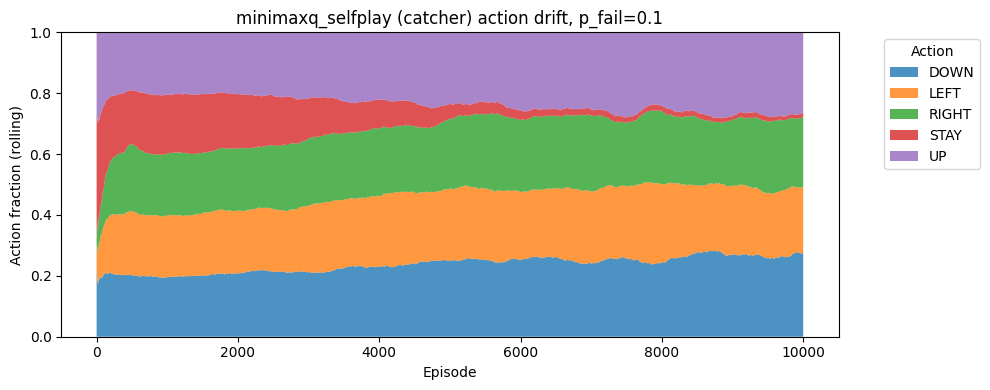

c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g.groupby(["episode", col])
c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:177: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_group)


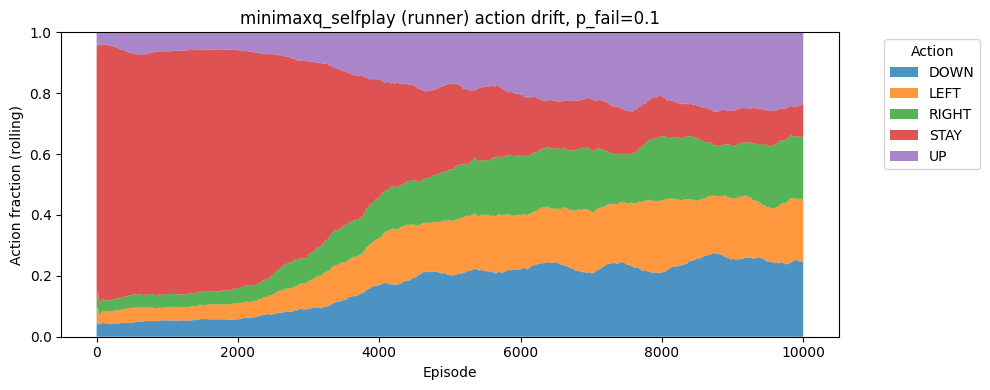

c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g.groupby(["episode", col])
c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:177: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_group)


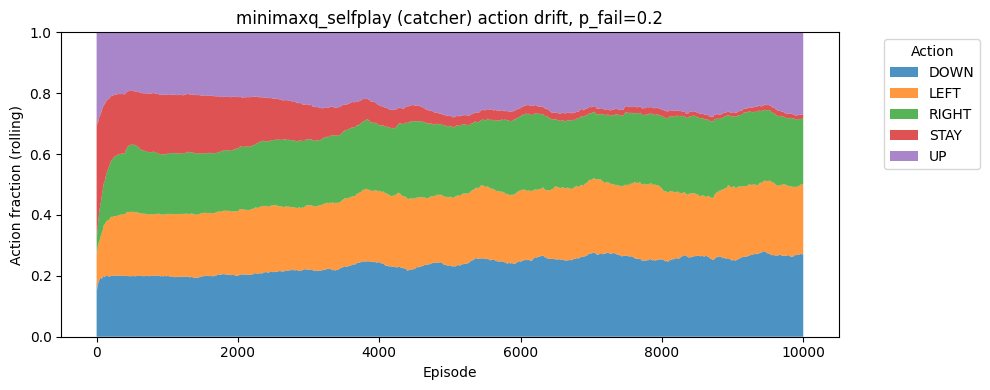

c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g.groupby(["episode", col])
c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:177: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_group)


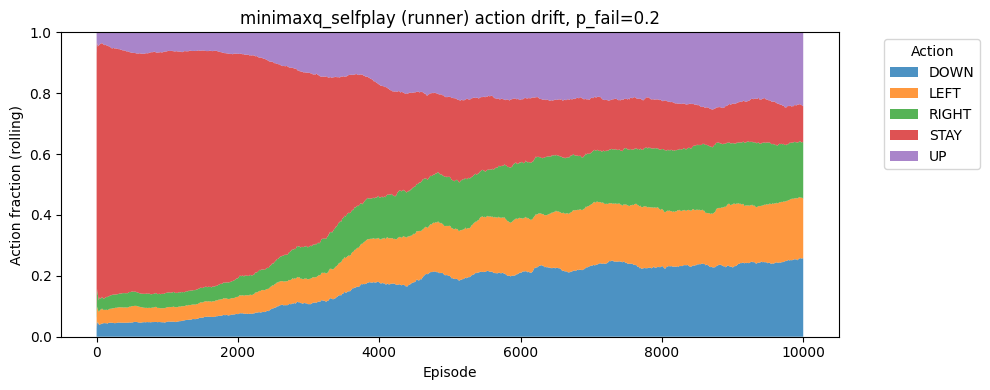

c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g.groupby(["episode", col])
c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:177: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_group)


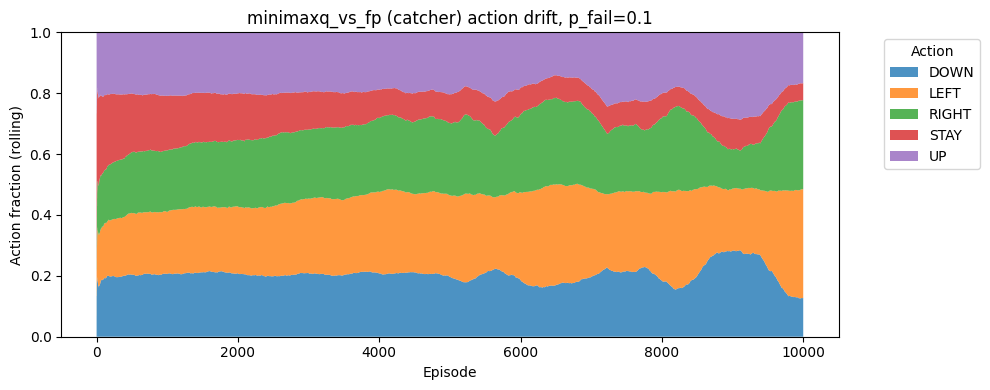

c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g.groupby(["episode", col])
c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:177: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_group)


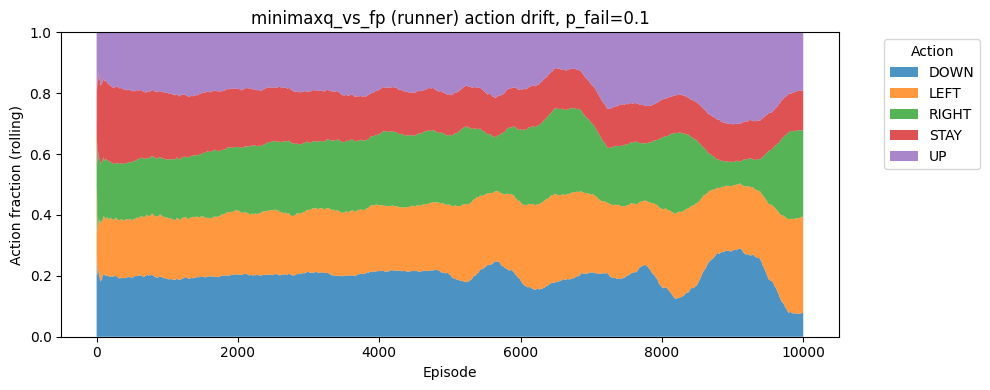

c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g.groupby(["episode", col])
c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:177: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_group)


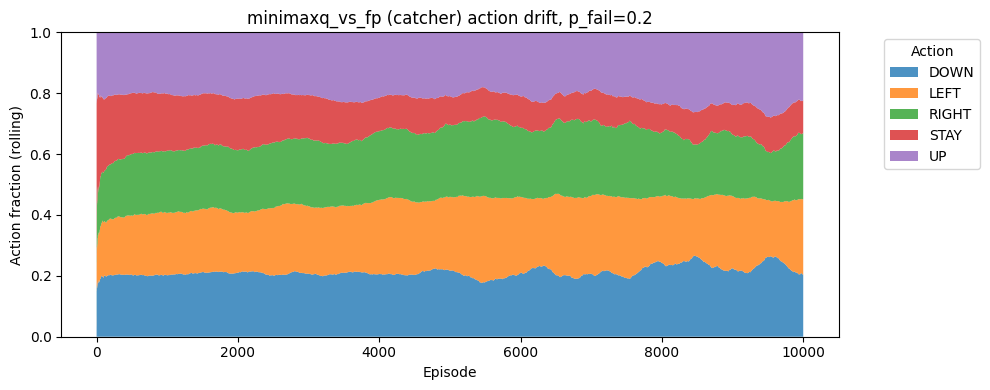

c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g.groupby(["episode", col])
c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:177: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_group)


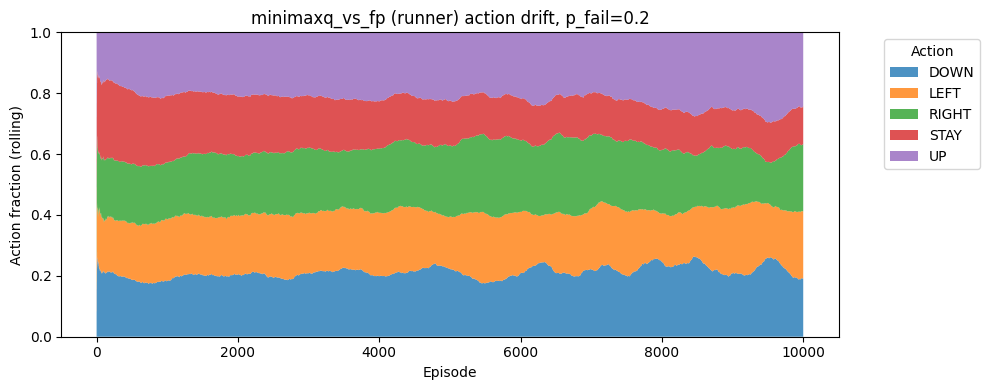

Action drift plots generated per run/p_fail.


In [8]:
if steps_df.empty:
    print('No steps data for action drift.')
else:
    for run in steps_df['run'].unique():
        for pf in sorted(steps_df.loc[steps_df['run']==run, 'p_fail'].dropna().unique()):
            sub = steps_df.loc[(steps_df['run']==run) & (steps_df['p_fail']==pf)]
            mix_c = rolling_action_mix(sub, who='catcher', window=ROLL_WINDOW)
            title_c = f"{run} (catcher) action drift, p_fail={pf}"
            plot_action_drift(mix_c, title=title_c)
            plt.show()
            mix_r = rolling_action_mix(sub, who='runner', window=ROLL_WINDOW)
            title_r = f"{run} (runner) action drift, p_fail={pf}"
            plot_action_drift(mix_r, title=title_r)
            plt.show()
    print('Action drift plots generated per run/p_fail.')


## 6. Return quantiles over training
Rolling quantiles (10/50/90%) of episode return per run and p_fail.


c:\Users\user\Desktop\MSc - AI\Εξάμηνο 1ο\Ευφυείς Πράκτορες και Πολυπρακτορικά Συστήματα\Assignment\chase\notebook\nb_utils.py:210: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_group)


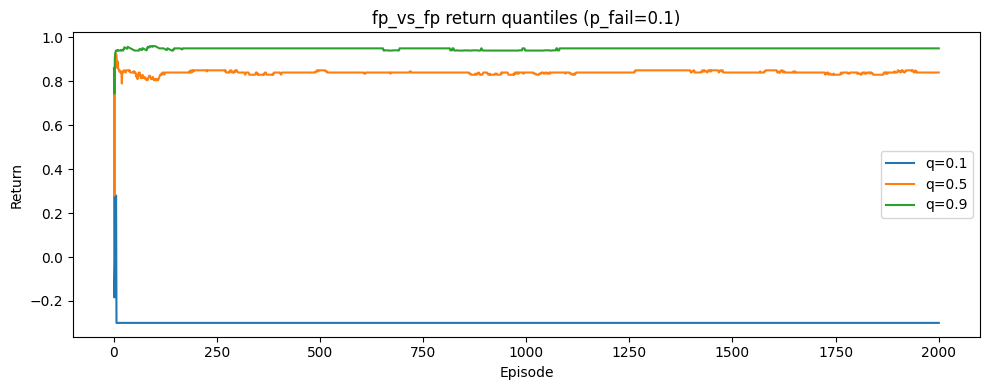

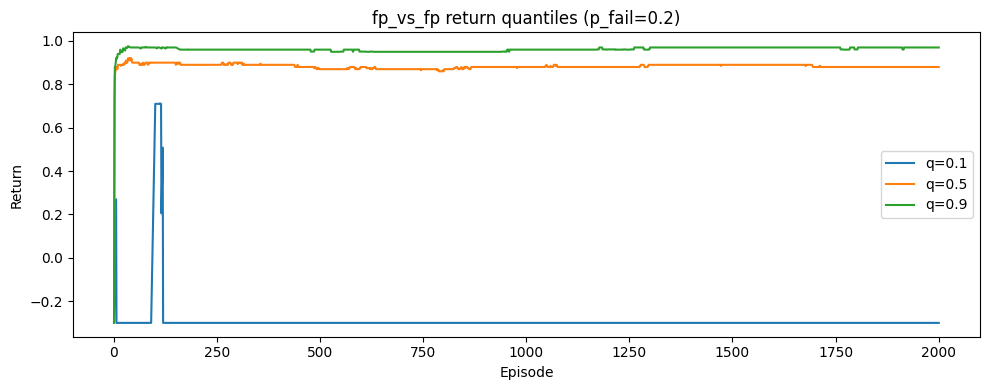

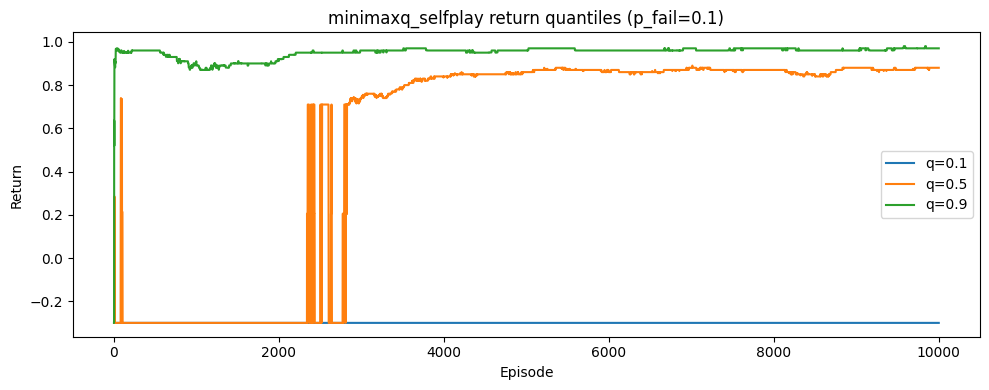

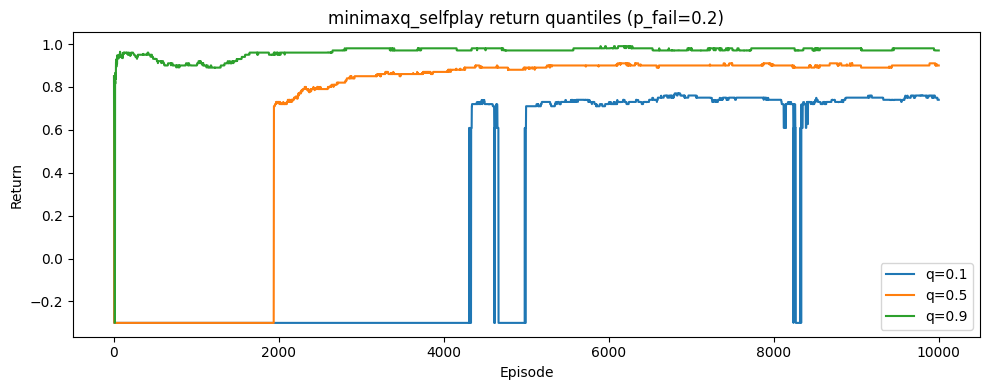

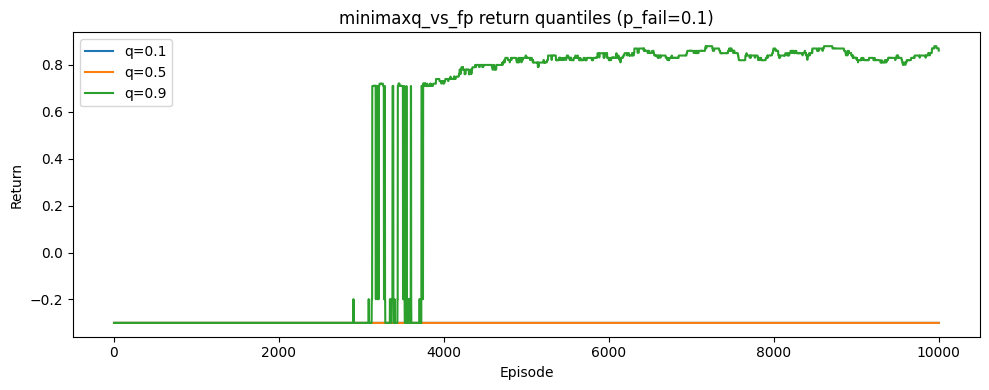

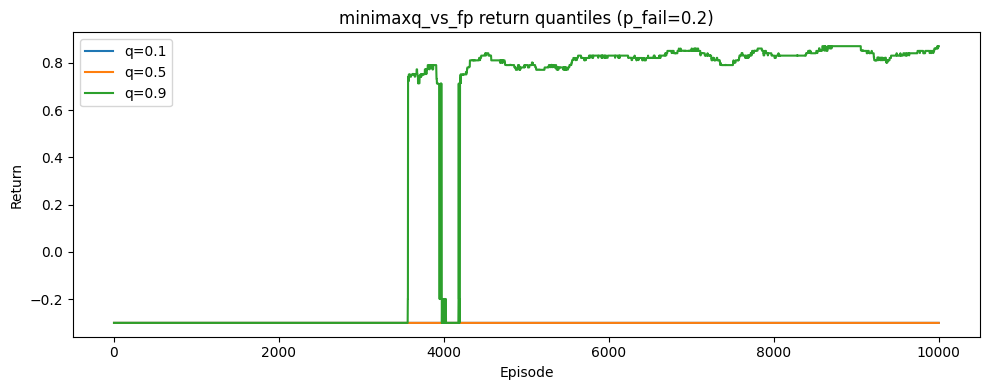

Return quantile plots generated per run/p_fail.


In [9]:
if ep_df.empty:
    print('No episode data for quantiles.')
else:
    quant_df = rolling_return_quantiles(ep_df, window=ROLL_WINDOW, quantiles=(0.1,0.5,0.9))
    for run in quant_df['run'].unique():
        for pf in sorted(quant_df.loc[quant_df['run']==run, 'p_fail'].dropna().unique()):
            sub = quant_df.loc[(quant_df['run']==run) & (quant_df['p_fail']==pf)]
            fig, ax = plt.subplots(figsize=(10,4))
            for q, g in sub.groupby('quantile'):
                ax.plot(g['episode'], g['value'], label=f"q={q}")
            ax.set_title(f"{run} return quantiles (p_fail={pf})")
            ax.set_xlabel('Episode')
            ax.set_ylabel('Return')
            ax.legend()
            fig.tight_layout()
            plt.show()
    print('Return quantile plots generated per run/p_fail.')


## 7. State-space heatmaps
Visit density and capture locations (catcher & runner) per run and p_fail.


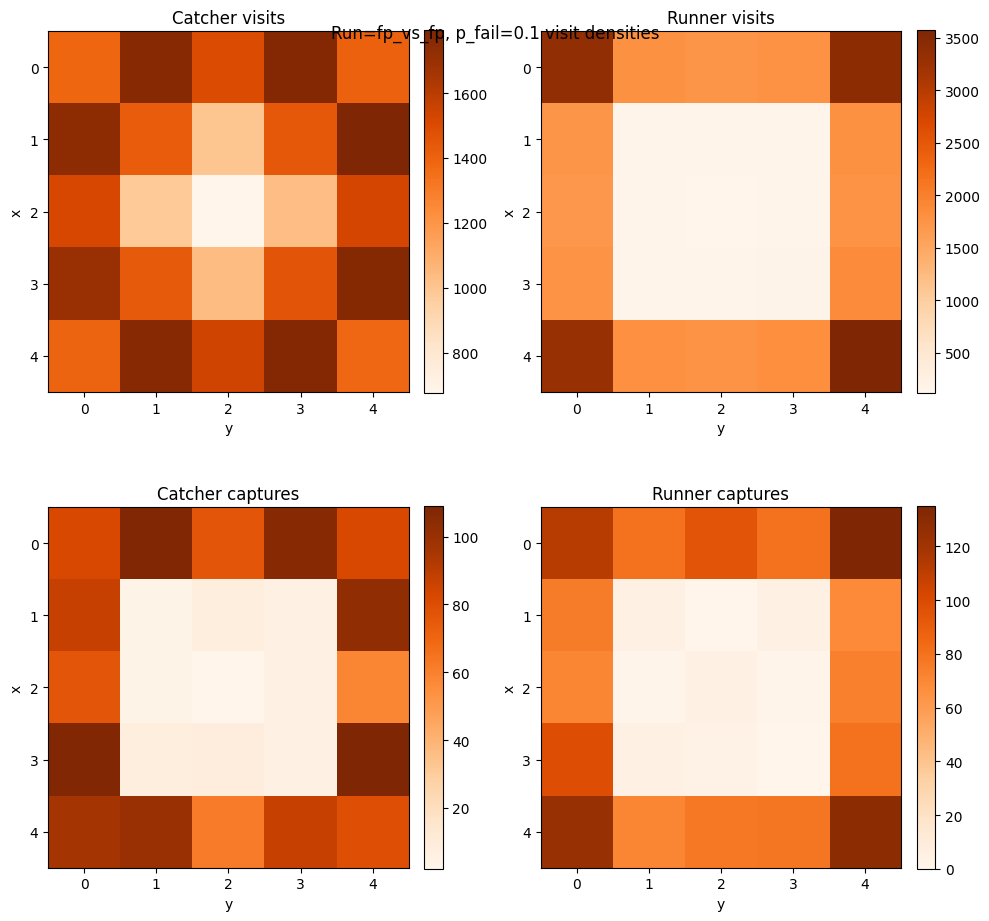

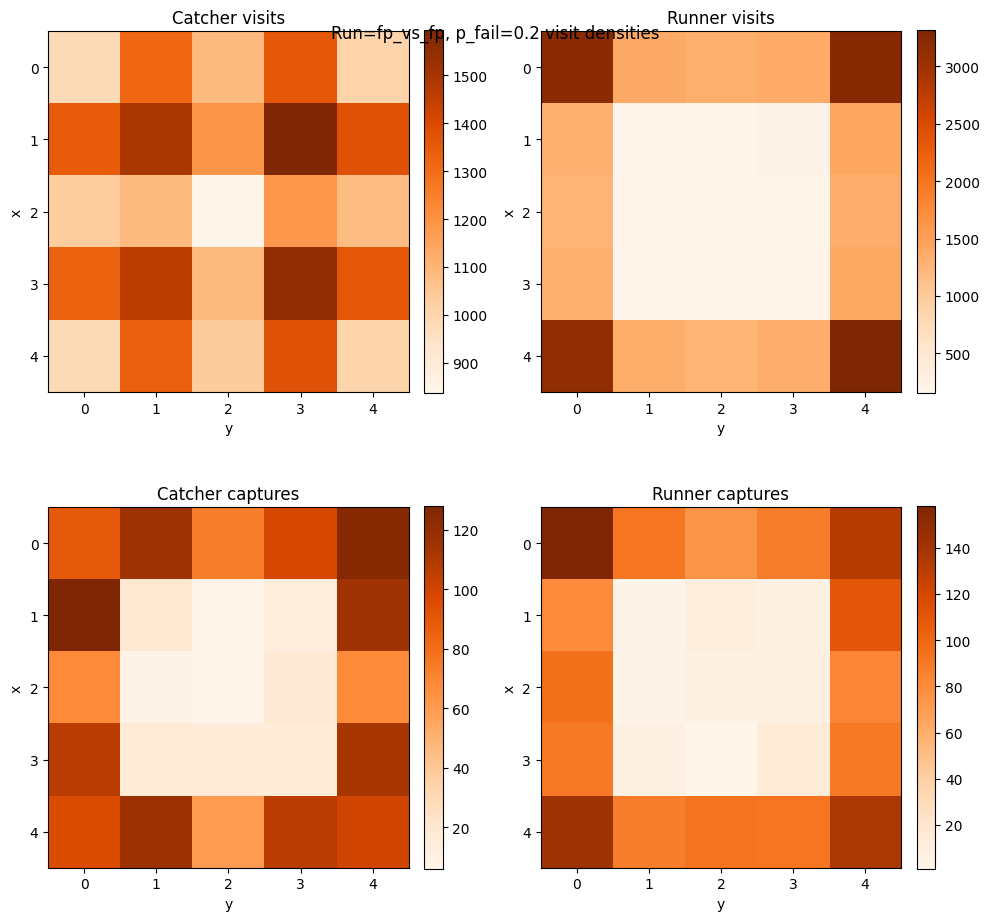

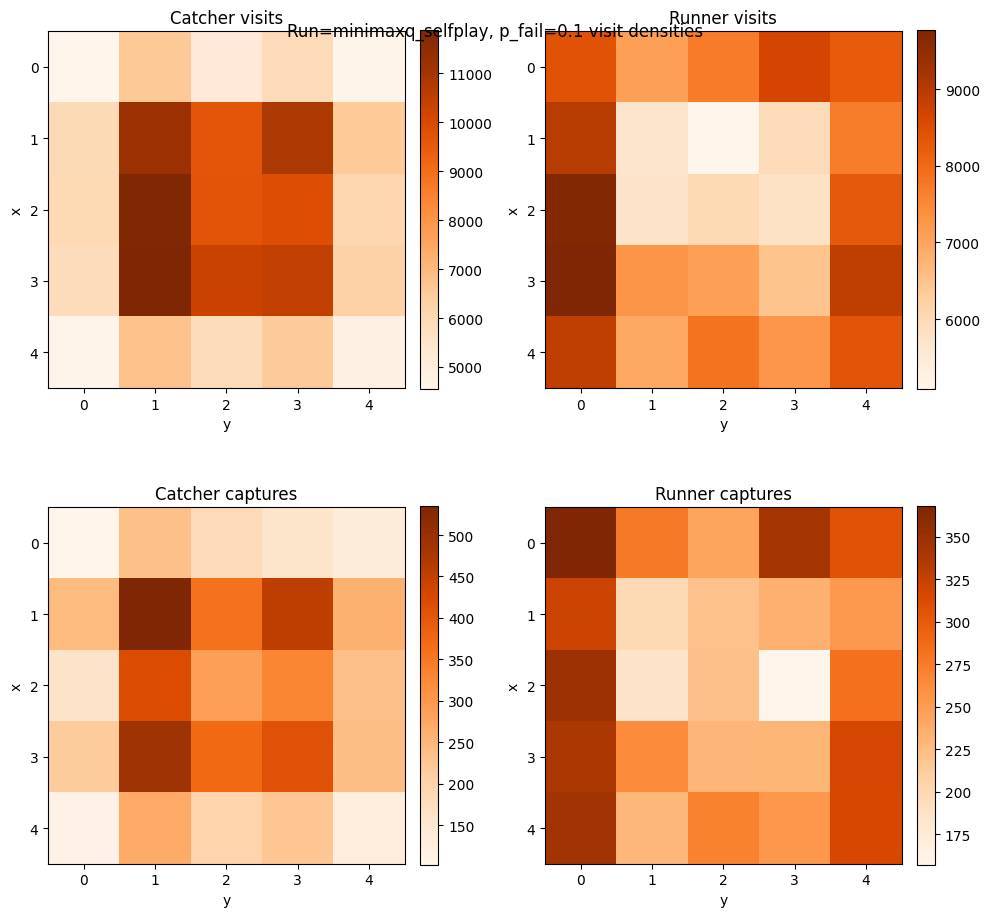

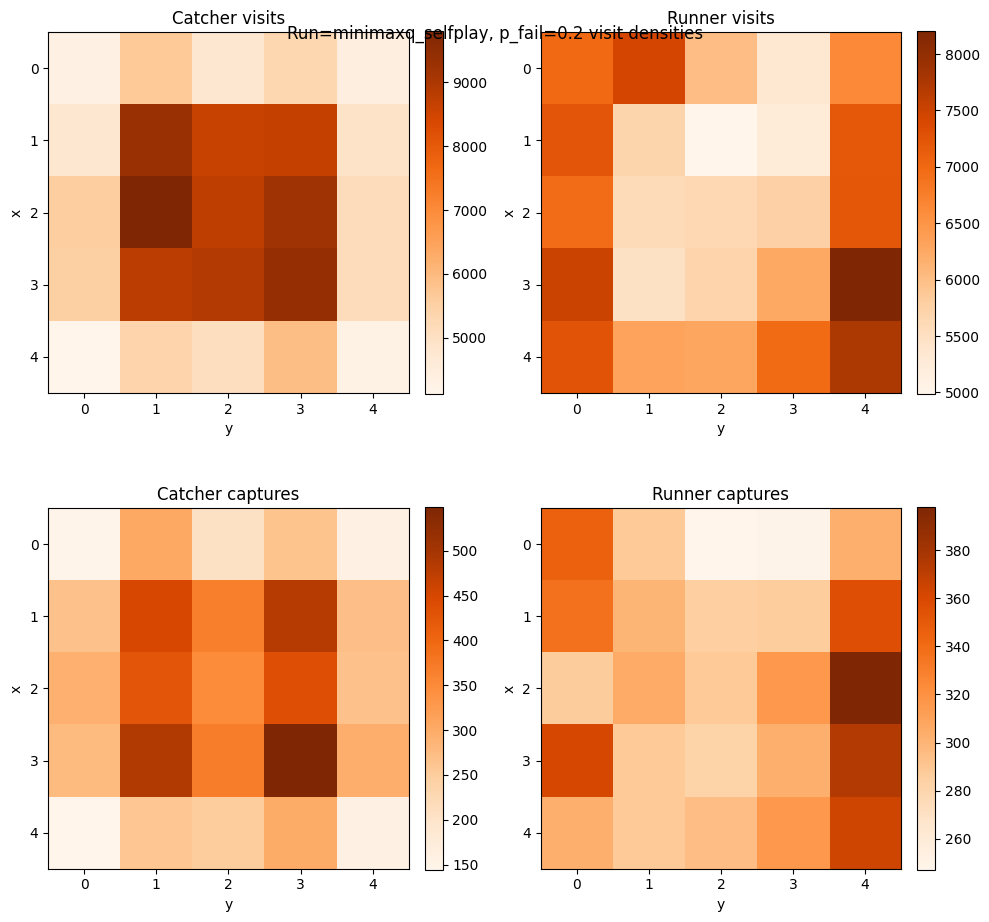

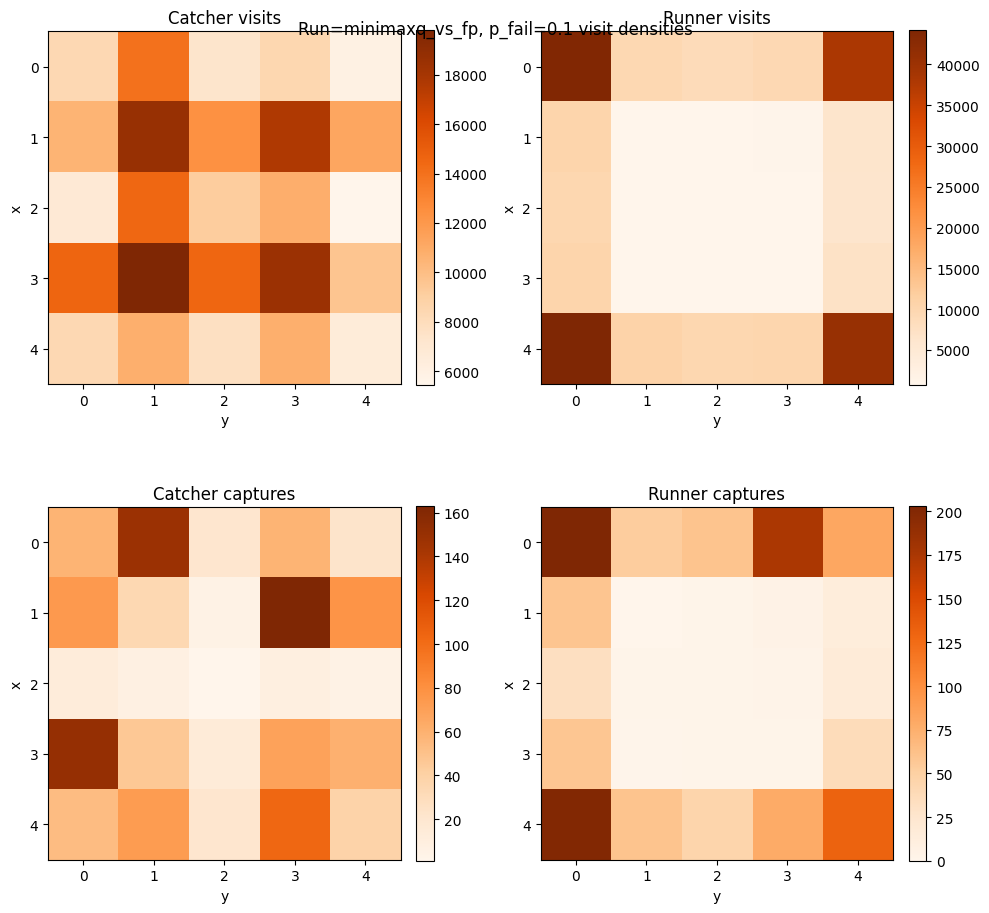

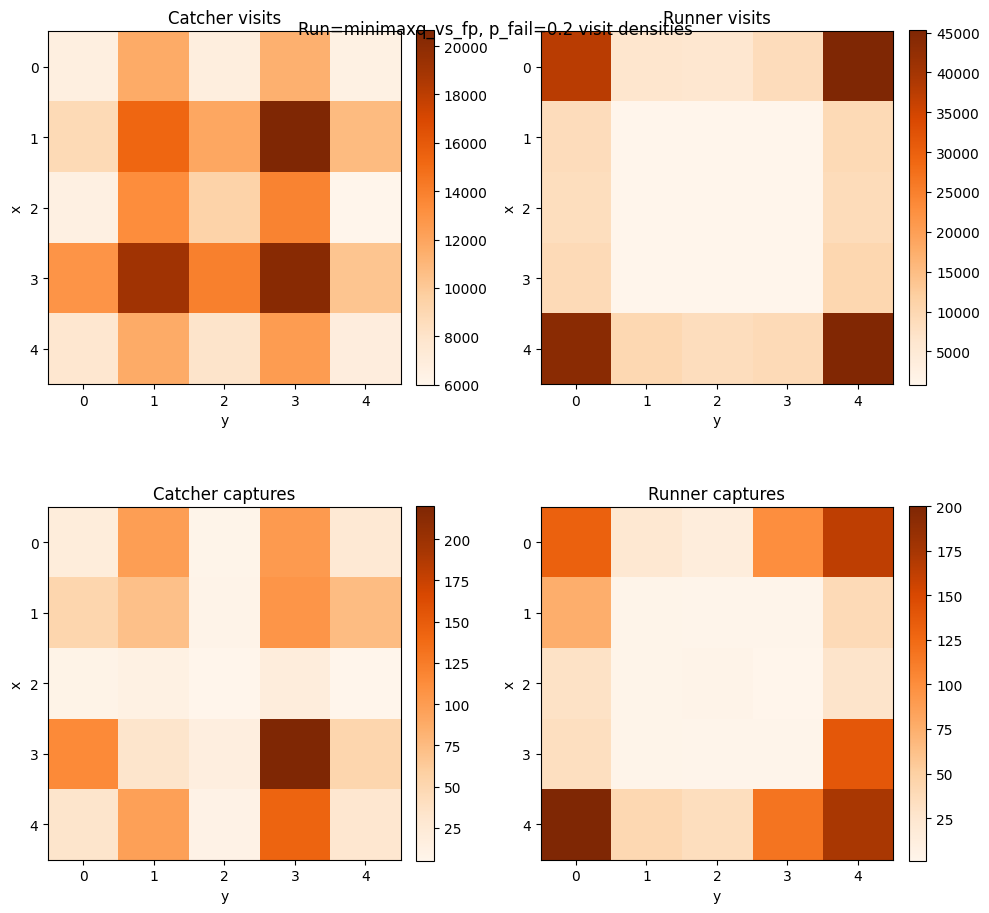

Heatmaps plotted per run/p_fail (visits + captures).


In [10]:
if steps_df.empty:
    print('No steps data for heatmaps.')
else:
    runs = steps_df['run'].unique()
    for run in runs:
        pfs = sorted(steps_df.loc[steps_df['run']==run, 'p_fail'].dropna().unique())
        for pf in pfs:
            plot_visit_heatmaps(steps_df, run=run, p_fail=pf)
            plt.show()
    print('Heatmaps plotted per run/p_fail (visits + captures).')


## 8. Overall comparison across runs & p_fail
Συγκεντρωτικό view όλων των runs ανά p_fail.


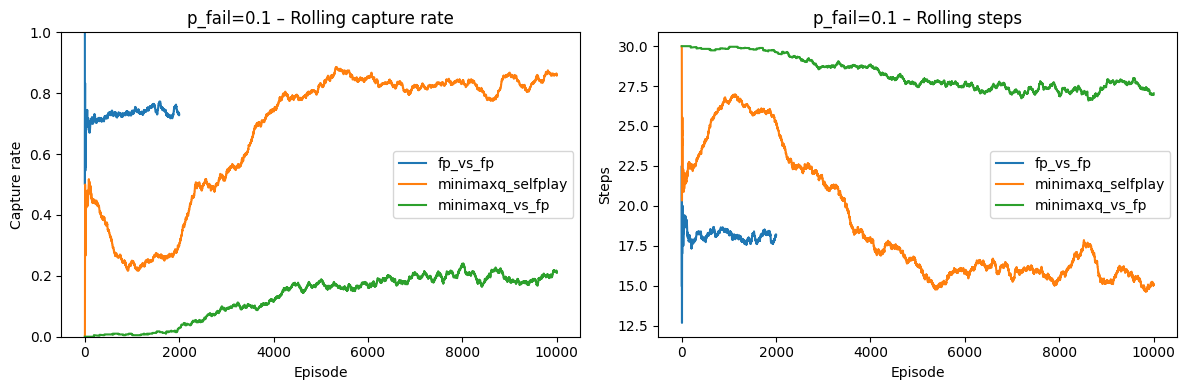

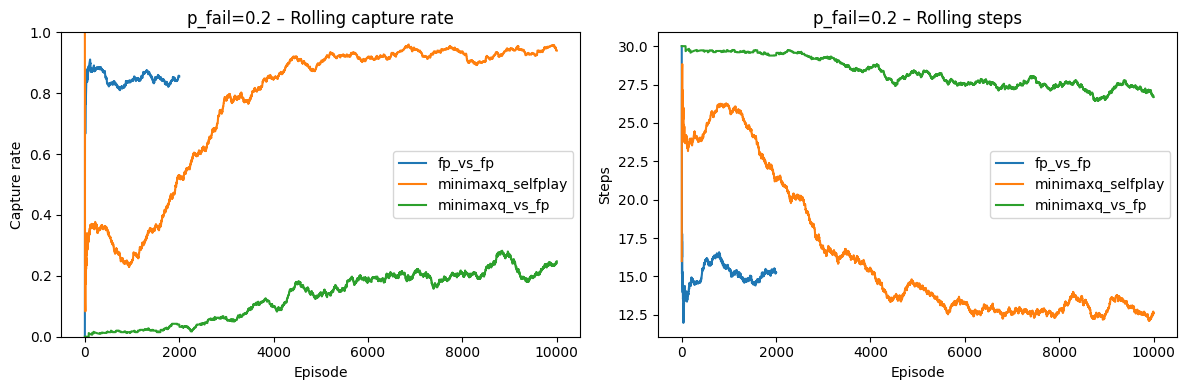

Capture/steps rolling curves plotted per p_fail. Summary table above shows averages.


In [11]:
if roll_df.empty:
    print('No data to compare.')
else:
    p_fails = sorted([pf for pf in roll_df['p_fail'].dropna().unique()])
    for pf in p_fails:
        pf_df = roll_df.loc[roll_df['p_fail'] == pf]
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
        for run in pf_df['run'].unique():
            sub = pf_df.loc[pf_df['run'] == run]
            axes[0].plot(sub['episode'], sub['roll_capture_rate'], label=run)
            axes[1].plot(sub['episode'], sub['roll_steps'], label=run)
        axes[0].set_title(f'p_fail={pf} – Rolling capture rate')
        axes[0].set_ylabel('Capture rate')
        axes[0].set_xlabel('Episode')
        axes[0].set_ylim(0, 1)
        axes[0].legend()
        axes[1].set_title(f'p_fail={pf} – Rolling steps')
        axes[1].set_ylabel('Steps')
        axes[1].set_xlabel('Episode')
        axes[1].legend()
        fig.tight_layout()
        plt.show()
    print('Capture/steps rolling curves plotted per p_fail. Summary table above shows averages.')
